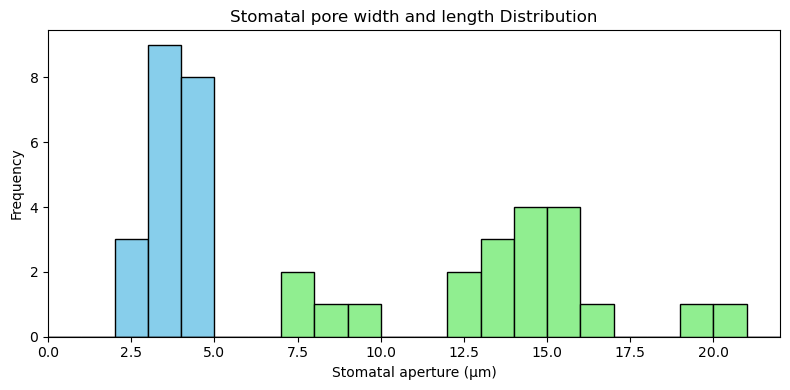

Mean width: 3.89 ± 0.10 µm
Mean length: 13.58 ± 1.50 µm


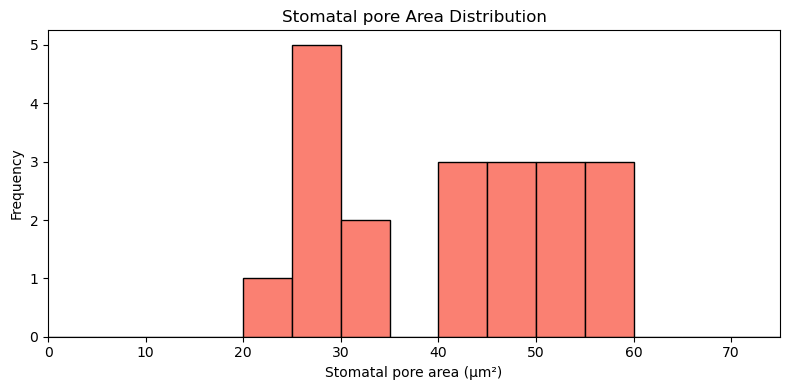

Mean area: 40.88 ± 4.72 µm²


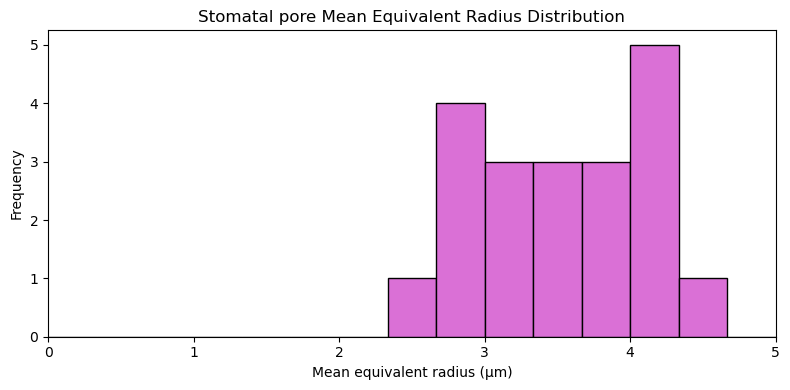

Mean equivalent radius: 3.56 ± 0.21 µm


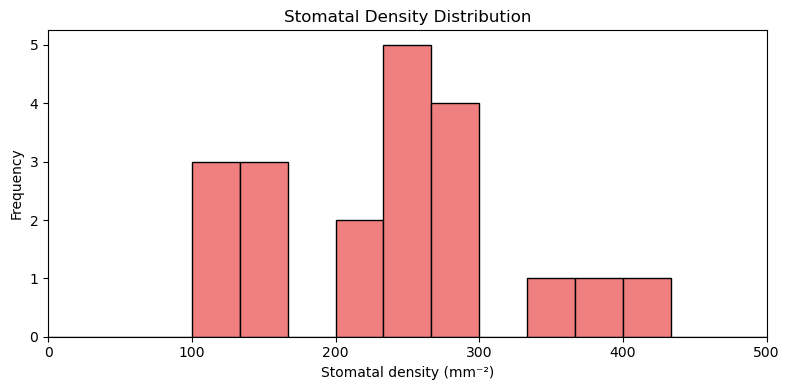

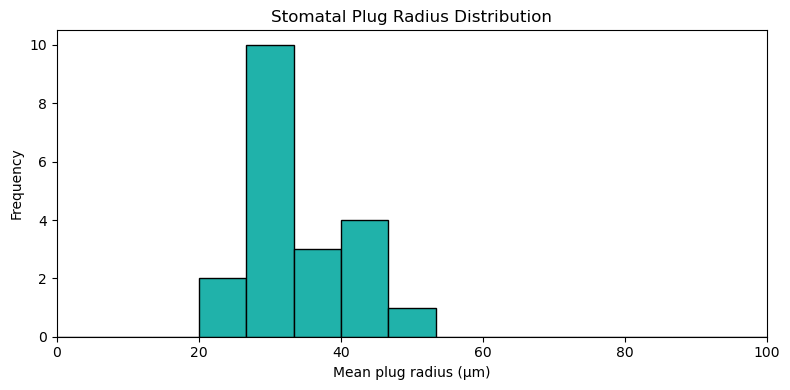

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

# We find stomatal aperture data from Devi & Reddy (2018). 
# The opening is rather elliptic, but we normalize area to a circle for simplicity.
# We also concatinate measurements from low and high VPD conditions 

widths = np.array([3.93, 3.33, 3.72, 3.87, 3.77, 4.69, 3.95, 4.82, 4.97, 4.86, 4.56, 3.43, 4.32, 3.68, 4.80, 3.01, 2.89, 2.41, 2.03, 4.66]) # µm
widths_err = 0.10 # µm (roughly)

lengths = np.array([13.2, 15.9, 20.5, 16.2, 19.8, 7.1, 8.18, 12.7, 13.3, 15.1, 7.09, 12.1, 14.1, 14.6, 13.5, 9.00, 14.3, 15.0, 15.7, 14.3]) # µm
lengths_err = 1.50 # µm (roughly)

stomatal_densities = np.array([150, 160, 120, 129, 100, 257, 285, 240, 140, 213, 280, 280, 244, 250, 200, 383, 400, 343, 260, 267]) # mm⁻²
densities_err = 8 # mm⁻² (roughly)
                             
                             
# plot histogram of distributions
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(widths, bins=22, range=(0, 22), color='skyblue', edgecolor='black', label='width')
ax.hist(lengths, bins=22, range=(0,22), color='lightgreen', edgecolor='black', label='length')
ax.set_xlim(0,22)
ax.set_xlabel('Stomatal aperture (µm)')
ax.set_ylabel('Frequency')
ax.set_title('Stomatal pore width and length Distribution')
plt.tight_layout()
plt.show()

print(f'Mean width: {np.mean(widths):.2f} ± {widths_err:.2f} µm')
print(f'Mean length: {np.mean(lengths):.2f} ± {lengths_err:.2f} µm')

area = np.pi / 4 * widths * lengths  # µm² 
area_err = area * np.sqrt((widths_err / widths)**2 + (lengths_err / lengths)**2)

# plot histogram of area distribution
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(area, bins=15, range=(0, 75), color='salmon', edgecolor='black', label='area')
ax.set_xlim(0,75)
ax.set_xlabel('Stomatal pore area (µm²)')
ax.set_ylabel('Frequency')
ax.set_title('Stomatal pore Area Distribution')
plt.tight_layout()
plt.show()

print(f'Mean area: {np.mean(area):.2f} ± {np.mean(area_err):.2f} µm²')

# calculate the radius of a circle with equivalent area and bootstrap the error
r_eq = np.sqrt(area / np.pi)  # µm
r_eq_err = 0.5 * r_eq * area_err / area  # µm

# plot histogram of equivalent radius distribution
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(r_eq, bins=15, range=(0, 5), color='orchid', edgecolor='black', label='equivalent radius')
ax.set_xlim(0,5)
ax.set_xlabel('Mean equivalent radius (µm)')
ax.set_ylabel('Frequency')
ax.set_title('Stomatal pore Mean Equivalent Radius Distribution')
plt.tight_layout()
plt.show()

print(f'Mean equivalent radius: {np.mean(r_eq):.2f} ± {np.mean(r_eq_err):.2f} µm')

# plot histograms of stomatal density distribution
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(stomatal_densities, bins=15, range=(0, 500), color='lightcoral', edgecolor='black', label='stomatal density')
ax.set_xlim(0,500)
ax.set_xlabel('Stomatal density (mm⁻²)')
ax.set_ylabel('Frequency')
ax.set_title('Stomatal Density Distribution')
plt.tight_layout()
plt.show()

plug_radii = 1e3 / np.sqrt(stomatal_densities) / 2 # µm

# plot histogram of plug radius distribution
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(plug_radii, bins=15, range=(0, 100), color='lightseagreen', edgecolor='black', label='plug radius')
ax.set_xlim(0,100)
ax.set_xlabel('Mean plug radius (µm)')
ax.set_ylabel('Frequency')
ax.set_title('Stomatal Plug Radius Distribution')
plt.tight_layout()
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: '../../figures/ stomatal_plug_radius_distribution.jpg'

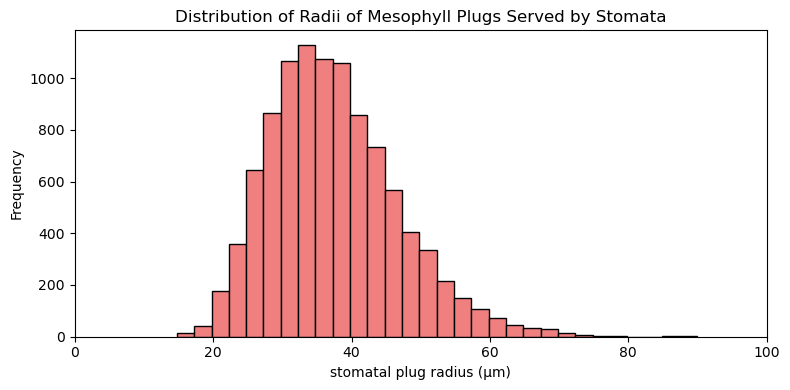

In [3]:
# Next we dive into stomatal spacing with data from (Liu et al., 2018)
# The stomatal density is given in #/mm²
# for uniformly distributed stomata, the distance between stomata can be approximated as: 1/√d 
#     where for random distributions, a correction factor of 1/2 is applied

# data from Liu et al. (2018)
density_min = 8.93 # #/mm²
density_mean = 189.56  
density_max = 632.44 

# distribution from Liu et al. is approximately log-normal
log_norm_fwhm = 0.5 
log_norm_std = log_norm_fwhm / (2 * np.sqrt(2 * np.log(2)))  # convert FWHM to std
log_norm_mean = np.log10(density_mean)


n = 10_000
# draw n samples from a normal distribution with log_norm_mean and log_norm_std
log_samples = np.random.normal(log_norm_mean, log_norm_std, n)
# exponentiate to get log-normal samples
density_samples = 10**log_samples  # #/mm²
# derive spacing samples in µm
spacing_samples = 1e3 / np.sqrt(density_samples)/2  # µm



# plot a histogram of the density samples
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(spacing_samples, bins=30, color='lightcoral', edgecolor='black')
ax.set_xlabel('stomatal plug radius (µm)')
ax.set_xlim(0, 100)
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Radii of Mesophyll Plugs Served by Stomata')
plt.tight_layout()
plt.savefig('../../figures/ stomatal_plug_radius_distribution.jpg', dpi=300)
plt.show()

print(f"spacing distribution parameters (-2s, mean, +2s): {np.percentile(spacing_samples, 2.5):.2f}, {np.mean(spacing_samples):.2f}, {np.percentile(spacing_samples, 97.5):.2f}")
print(f"spacing paper parameters (min, mean, max): {1e3/np.sqrt(density_max)/2:.2f}, {1e3/np.sqrt(density_mean)/2:.2f}, {1e3/np.sqrt(density_min)/2:.2f}")

In [5]:
# Luo et al. 2023

L = np.array([377, 296, 386, 306, 392, 306])
d = np.array([221, 204, 205, 197, 261, 242])
R = 1e3 / np.sqrt(d) / 2  # µm 
a = np.array([305, 311, 322, 338, 332, 357]) # µm^2
r = np.sqrt(a / np.pi)  # µm

print(R, "\t", np.mean(R))
print(R/L, "\t", np.mean(R/L))
print(r, "\t", np.mean(r))
print(r/L, "\t", np.mean(r/L))

[33.6336397  35.0070021  34.92151479 35.62352499 30.94922303 32.14121733] 	 33.71268698985325
[0.0892139  0.1182669  0.09047025 0.11641675 0.0789521  0.10503666] 	 0.09972609146740914
[ 9.85314748  9.94959168 10.12402012 10.37249929 10.28002345 10.66004828] 	 10.206555050918492
[0.02613567 0.03361349 0.02622803 0.03389706 0.02622455 0.03483676] 	 0.0301559252889958
